In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn import decomposition

In [2]:
measurements = pd.read_csv(
    "/mnt/data/processed/measurements.median_signal_normalized_all.csv"
)
samples = pd.read_csv(
    "/mnt/data/processed/samples.csv"
)
features = pd.read_csv(
    "/mnt/data/processed/features.csv"
)

## 1. Sample PCA

In [3]:
measurements_wide = measurements.merge(
    samples.loc[samples.SampleType == "Sample", ["PlateId", "PlatePosition"]],
    how="inner"
).merge(
    features.loc[features.Type == "Protein", "ProbeId"],
    how="inner"
).pivot(
    index=["PlateId", "PlatePosition"],
    columns="ProbeId"
)

In [4]:
pca = decomposition.PCA()
X = pca.fit_transform(measurements_wide)

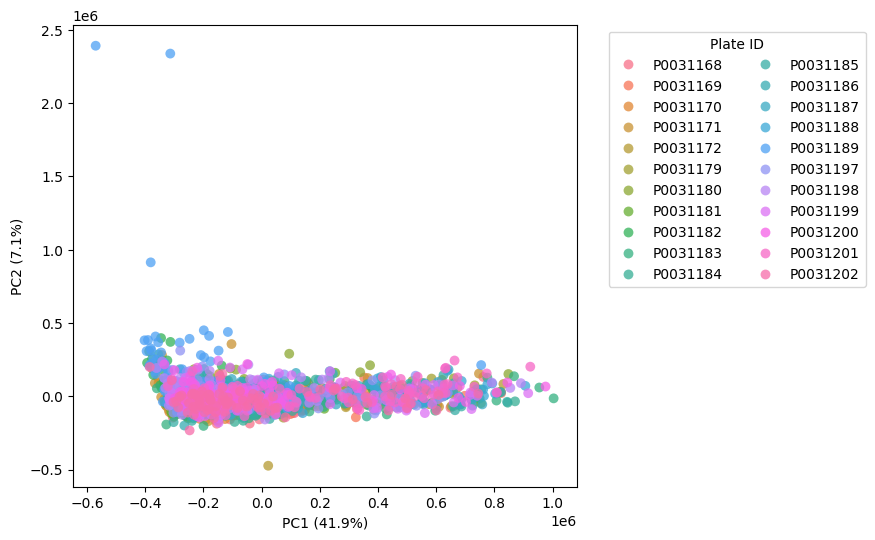

In [8]:
fig = plt.figure(figsize = [6.5, 6])

ax = sns.scatterplot(
    x = X[:, 0],
    y = X[:, 1],
    hue = measurements_wide.reset_index().PlateId,
    s = 50,
    linewidth = 0,
    alpha = .75
)

ax.legend(
    title = "Plate ID",
    ncol=2,
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
)
plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)

plt.show()

In [9]:
select = np.logical_and(
    X[:, 1] > -0.3*1e6, X[:, 1] < 0.5*1e6
)
sum(select)

np.int64(1802)

In [10]:
measurements_wide_filtered = measurements_wide.loc[select, :]

In [11]:
pca = decomposition.PCA()
X = pca.fit_transform(measurements_wide_filtered)

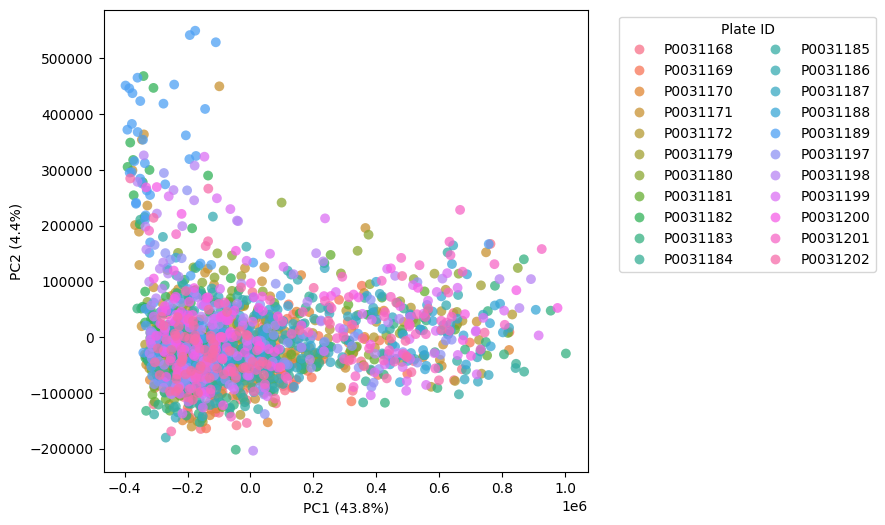

In [12]:
fig = plt.figure(figsize = [6.25, 6])

ax = sns.scatterplot(
    x = X[:, 0],
    y = X[:, 1],
    hue = measurements_wide_filtered.reset_index().PlateId,
    s = 50,
    linewidth = 0,
    alpha = .75
)

ax.legend(
    title = "Plate ID",
    ncol=2,
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
ax.set_xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
)
ax.set_ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)

plt.show()

## 2. Calibrator CV

In [13]:
measurements_calibrators = samples.loc[
    samples.SampleType == "Calibrator",
    ["PlateId", "PlatePosition"]
].merge(
    measurements
)

In [14]:
std = measurements_calibrators.groupby(["PlateId", "ProbeId"]).value.std()
mean = measurements_calibrators.groupby(["PlateId", "ProbeId"]).value.mean()
cv = (100 * std/mean).to_frame().reset_index()

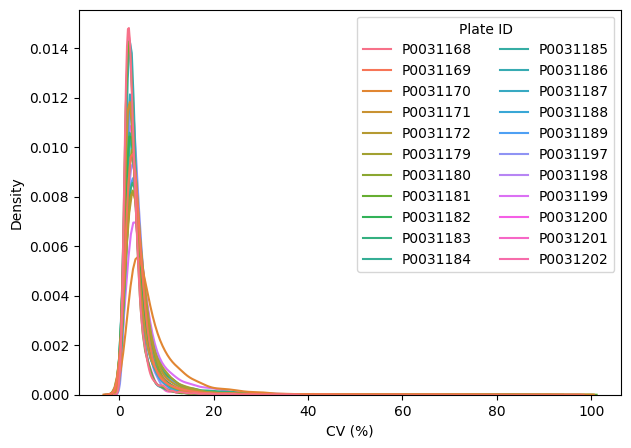

In [15]:
fig = plt.figure(figsize = [7, 5])

ax = sns.kdeplot(
    data=cv[cv.value < 100],
    x="value",
    hue="PlateId"
)

plt.xlabel("CV (%)")
handles = ax.get_legend().legend_handles
labels = [t.get_text() for t in ax.get_legend().get_texts()]
ax.legend(handles, labels, title="Plate ID", ncol=2, bbox_to_anchor=(1, 1))

plt.show()